In [ ]:
import pandas as pd
print("Hello, IELE756!")
print(f"pandas version: {pd.__version__}")

Hello, IELE756!
pandas version: 2.1.4


En esta celda se importa la librería pandas, que se utiliza para manipular y analizar datos en Python.
Luego se imprime un mensaje de prueba para verificar que el notebook está funcionando correctamente.
Finalmente, se muestra la versión de pandas instalada, lo cual es útil para asegurar compatibilidad con el código utilizado.

# Tarea 0 --- IELE756 
**Team members**: [ Tomas Allende] , [ Felipe Castillo]
**Region**: [ Magallanes]   #Antes de la asignacion de regiones lo hicimos con magallanes
**Date**: [ 13/3/2026]

In [50]:

persona = pd.read_parquet(
    "personas_censo2024.parquet",
    columns=["region","comuna","sexo","edad",
             "p27_nacionalidad","p27_nacionalidad_rec",
             "escolaridad","sit_fuerza_trabajo"]
)

En esta celda se carga la base de datos del Censo 2024 utilizando el formato Parquet, que es eficiente para trabajar con grandes volúmenes de datos.
Se seleccionan solo algunas columnas relevantes
Esto permite reducir el tamaño del dataset en memoria y trabajar solo con la información necesaria.

In [51]:
persona.shape


(18480432, 8)

Esta instrucción muestra las dimensiones del dataset cargado.
Sirve para verificar que la base de datos se cargó correctamente.

In [52]:
persona.dtypes

region                    int32
comuna                    int32
sexo                      int32
edad                      int32
p27_nacionalidad          int32
p27_nacionalidad_rec      int32
escolaridad               int32
sit_fuerza_trabajo      float64
dtype: object

Esta celda muestra el tipo de dato de cada columna del dataset.
Esto es importante porque permite saber cómo se pueden manipular los datos posteriormente.

In [53]:
persona.head(10)


,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0
5,4,4303,2,65,1,1,12,3.0
6,4,4303,1,58,1,1,15,1.0
7,11,11202,2,-66,-66,1,8,1.0
8,11,11202,1,-66,-66,1,5,1.0
9,11,11202,1,-66,-66,1,3,NaN


Aquí se muestran las primeras 10 filas del dataset.

In [54]:
persona.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18480432 entries, 0 to 18480431
Data columns (total 8 columns):
 #   Column                Dtype  
---  ------                -----  
 0   region                int32  
 1   comuna                int32  
 2   sexo                  int32  
 3   edad                  int32  
 4   p27_nacionalidad      int32  
 5   p27_nacionalidad_rec  int32  
 6   escolaridad           int32  
 7   sit_fuerza_trabajo    float64
dtypes: float64(1), int32(7)
memory usage: 634.5 MB


Esta función entrega un resumen completo del dataframe. Es útil para detectar valores faltantes o problemas en los datos.

In [ ]:
my_region = persona[persona["region"] == 12]
print(f"Rows in my region: {len(my_region):,}")

Rows in my region: 166,537


En esta celda se filtran los datos del censo para una región específica.
En este caso:

region == 12 corresponde a Magallanes
Se crea un nuevo dataframe llamado my_region que contiene solo las personas de esa región.

Luego se imprime el número total de registros.

In [56]:
foreign = my_region["p27_nacionalidad_rec"] \
    .value_counts(normalize=True)
print(f"% foreign-born: {foreign.get('Extranjero', 0):.1%}")

% foreign-born: 0.0%


Esta celda calcula la proporción de personas extranjeras en la región.
Pasos:
Se cuentan las nacionalidades con value_counts().
normalize=True convierte los conteos en porcentajes.
Se extrae el valor correspondiente a "Extranjero".
Se imprime el porcentaje.
Esto permite medir la presencia de población migrante en la región.

In [ ]:
eno = pd.read_csv(
  "20241218_base_eno_final.csv",
 sep=";", encoding="utf-8-sig")
print(f"Total: {len(eno):,}")
print(eno.columns.tolist())

C:\Users\t1te\AppData\Local\Temp\ipykernel_32500\2531376163.py:2: DtypeWarning: Columns (6,11,12,13,14,15,16,17,18,19,20,22,23,24,25,26,27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  eno = pd.read_csv(


Total: 333,300
['etapa_clinica', 'region', 'seremi', 'nacionalidad', 'cie_10_diagnostico', 'diagnostico', 'Autóctono', 'anho_notificacion', 'ENO', 'pueblo_indigena', 'nombre_instruccion', 'presenta_sintomas', 'sintomas', 'consumo_agua_no_potable', 'antecedente_teniasis', 'imagenologia', 'manifestaciones', 'existe_coinfeccion', 'via_transmision', 'n_parejas_sexuales', 'uso_preservativo', 'pais_contagio', 'paciente_inmunosuprimido', 'vih', 'pareja', 'exantema_mpox', 'factores_exposicion', 'neumonia', 'contacto_aves', 'genotipo_1', 'recuento_linfocitos', 'clasificacion_final_vih', 'etapa_vih_sida', 'hospitalizacion', 'nombre_primer_sintoma', 'SeroGrupo', 'sexo', 'grupo_edad', 'codigo_comuna_residencia']


Aquí se carga una segunda base de datos correspondiente a ENO (Enfermedades de Notificación Obligatoria).

In [8]:
eno.head()

,etapa_clinica,region,seremi,nacionalidad,cie_10_diagnostico,diagnostico,Autóctono,anho_notificacion,ENO,pueblo_indigena,...,genotipo_1,recuento_linfocitos,clasificacion_final_vih,etapa_vih_sida,hospitalizacion,nombre_primer_sintoma,SeroGrupo,sexo,grupo_edad,codigo_comuna_residencia
0,CONFIRMADA,Región de Tarapacá,TARAPACÁ,Extranjero,A97.0,DENGUE SIN DATOS DE ALARMA,No,2020,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mujer,25-29,01107
1,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Desconocido,A90.X,FIEBRE DEL DENGUE,No,2018,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hombre,70-74,05301
2,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,No,2020,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,mujer,70-74,05109
3,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Extranjero,A97.0,DENGUE SIN DATOS DE ALARMA,No,2019,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hombre,40-44,05301
4,CONFIRMADA,Región de Valparaíso,VALPARAÍSO,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,No,2021,Arbovirus,Desconocido,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,hombre,60-64,05109


Muestra las primeras filas del dataset ENO

In [19]:
eno_region = eno[eno["region"] == "Región de Magallanes y la Antártica Chilena"]
print(f"Magallanes y la Antártica Chilena: {len(eno_region):,}")

Magallanes y la Antártica Chilena: 3,208


Se filtran los registros de ENO para la región de Magallanes.
Se crea un nuevo dataframe eno_region que contiene solo esos casos.
Luego se imprime el número de registros encontrados.

In [13]:
eno_tar["ENO"].value_counts().head(10)

ENO
Parotiditis                       1012
Sifilis                            821
VIH                                523
Hepatitis B                        278
Hidatidosis (Equinococosis)        184
Infección gonocócica               157
Hepatitis A                         53
Hepatitis C                         49
Fiebre Tifoidea y Paratifoidea      31
Chagas                              29
Name: count, dtype: int64

Esta celda calcula las enfermedades más notificadas en el dataset ENO.
value_counts() cuenta cuántas veces aparece cada enfermedad.
head(10) muestra las 10 más frecuentes.

C:\Users\t1te\AppData\Local\Temp\ipykernel_32500\4267797553.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eno_region["anho_notificacion"] = eno_region["anho_notificacion"].astype(int)


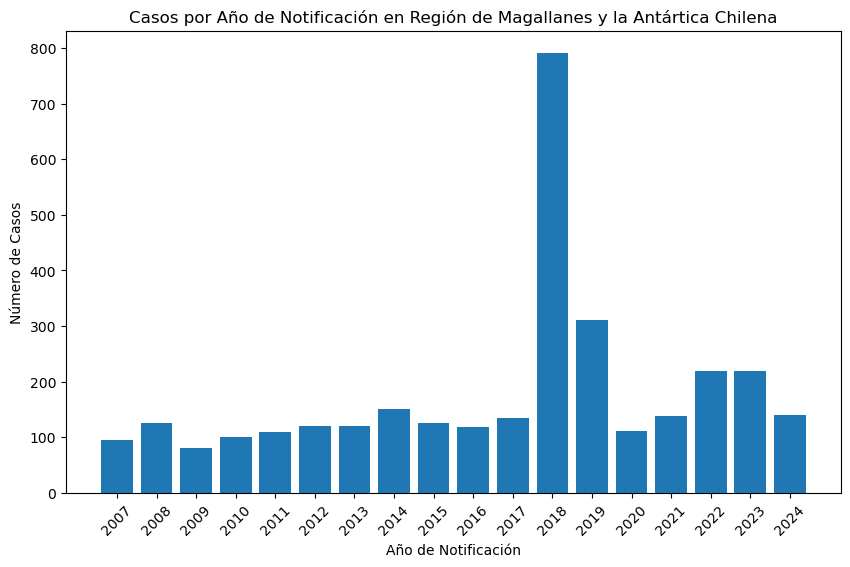

In [16]:
import matplotlib.pyplot as plt

eno_region["anho_notificacion"] = eno_region["anho_notificacion"].astype(int)
counts = eno_region["anho_notificacion"].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values)

plt.xlabel("Año de Notificación")
plt.ylabel("Número de Casos")
plt.title("Casos por Año de Notificación en Región de Magallanes y la Antártica Chilena")

plt.xticks(counts.index, counts.index, rotation=45)

plt.show()

Se convierte la variable anho_notificacion a formato numérico.
Se cuentan los casos por año.
Se ordenan cronológicamente.
Se genera un gráfico de línea o barras con matplotlib.
Esto permite analizar la evolución de enfermedades notificadas en el tiempo.

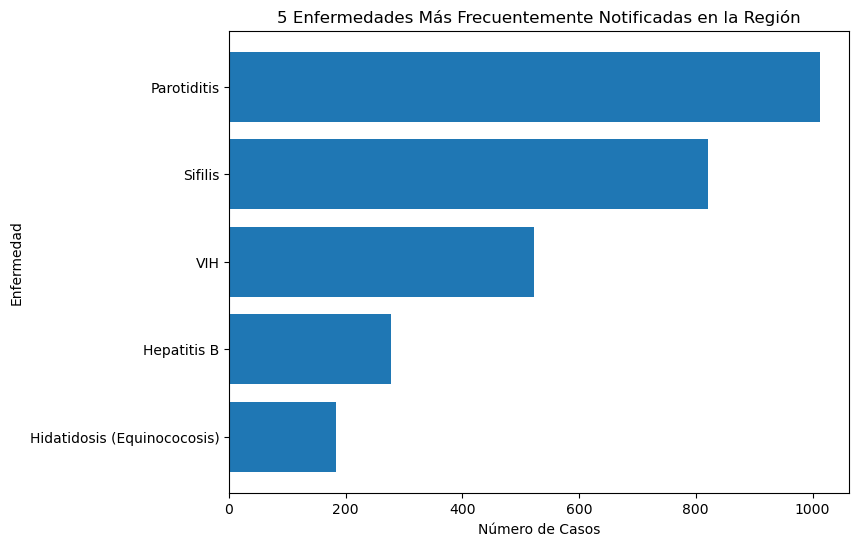

In [20]:
import matplotlib.pyplot as plt

# Obtener las 5 enfermedades más notificadas
top5 = eno_region["ENO"].value_counts().head(5)

# Crear gráfico horizontal
plt.figure(figsize=(8,6))
plt.barh(top5.index, top5.values)

plt.xlabel("Número de Casos")
plt.ylabel("Enfermedad")
plt.title("5 Enfermedades Más Frecuentemente Notificadas en la Región")

plt.gca().invert_yaxis()  # la más frecuente queda arriba

plt.show()

Se identifican las 5 enfermedades con mayor número de casos.
Se construye un gráfico de barras horizontal.
El gráfico permite visualizar rápidamente cuáles son las enfermedades más frecuentes.

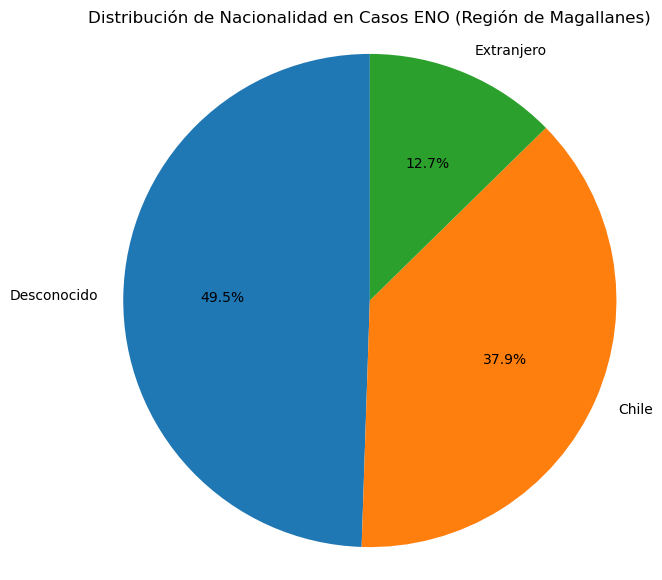

In [23]:
import matplotlib.pyplot as plt

# Contar nacionalidades
nacionalidad_counts = eno_region["nacionalidad"].value_counts()

# Crear gráfico de torta
plt.figure(figsize=(7,7))
plt.pie(
    nacionalidad_counts.values,
    labels=nacionalidad_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribución de Nacionalidad en Casos ENO (Región de Magallanes)")
plt.axis("equal")  # mantiene el círculo perfecto

plt.show()

Gráfico de nacionalidad de los pacientes.

In [43]:
import zipfile
cols = ["COMUNA", "NACIONALIDAD", "SEXO", "DIAGNOSTICO1",
 "FECHA_INGRESO", "FECHAALTA",
 "IR_29301_SEVERIDAD", "IR_29301_COD_GRD"]
with zipfile.ZipFile("GRD_PUBLICO_2024.zip") as z:
 with z.open("GRD_PUBLICO_2024.txt") as f:
  grd = pd.read_csv(f, sep="|", usecols=cols, low_memory=False, encoding="latin-1") 

print(f"Total discharges: {len(grd):,}")

Total discharges: 1,085,813


Lectura de base hospitalaria GRD desde un archivo comprimido.
Se abre un archivo .zip que contiene datos hospitalarios.
Se seleccionan solo algunas columnas relevantes

In [45]:
my_comunas = [
    "PUNTA ARENAS",
    "PUERTO NATALES",
    "PORVENIR",
    "PRIMAVERA",
    "TIMAUKEL",
    "TORRES DEL PAINE",
    "LAGUNA BLANCA",
    "RIO VERDE",
    "SAN GREGORIO",
    "CABO DE HORNOS",
    "ANTARTICA"
]

grd_region = grd[grd["COMUNA"].isin(my_comunas)]
print(f"Discharges in my region: {len(grd_region):,}")

Discharges in my region: 12,943


Se crea una lista con las comunas de la región.
Luego se filtra el dataset para quedarse solo con esas comunas, generando el dataframe grd_region.

In [46]:
cie10 = pd.read_excel("CIE-10.xlsx",
                       sheet_name="CIE 10")
grd_region = grd_region.merge(
 cie10[["Código", "Descripción", "Capítulo"]],
 left_on="DIAGNOSTICO1", right_on="Código",
 how="left")

Aquí se realiza un merge (join) entre:
la base hospitalaria
la base CIE-10
Esto permite transformar el código del diagnóstico en:
descripción de la enfermedad
capítulo médico
De esta forma los diagnósticos se vuelven interpretables.

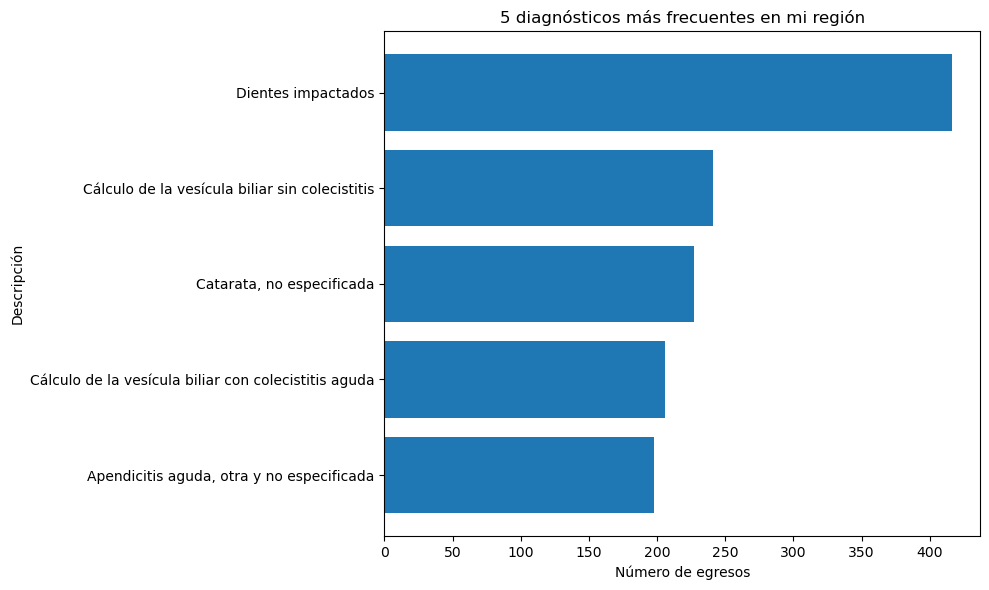

In [47]:
import matplotlib.pyplot as plt

top5 = grd_region["Descripción"].value_counts().head(5)

plt.figure(figsize=(10, 6))
plt.barh(top5.index, top5.values)

plt.xlabel("Número de egresos")
plt.ylabel("Descripción")
plt.title("5 diagnósticos más frecuentes en mi región")

plt.gca().invert_yaxis()  # deja el más frecuente arriba
plt.tight_layout()
plt.show()

Gráfico de diagnósticos más frecuentes.